<a href="https://colab.research.google.com/github/Ilginceylan/swps-data-analysis-2026/blob/main/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9. Exploratory data analysis - exercises

All of the exercises are based on lecture (https://github.com/agazbrzezny/DAT-SWPS-2026/blob/main/statistics.ipynb) and examples presented there.

## Exercises

**Task 1**

Use the [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease) dataset, and then:
* 1.1 Check the data card to see which features are numerical and which are categorical. Check how the pandas library loads this data by default. If a categorical feature is marked as numerical in the table, change it to categorical (pandas has a `category` data type).
* 1.2 Check if there are any missing values in the dataset. If so, before proceeding with the next tasks, prepare a subset of the data that does not contain observations with missing values.

**Task 2**

For the dataset from Task 1, calculate and display:
* 2.1 The distribution of values in the `num` column (Target) – is the data balanced? Display it in a pie chart.
* 2.2 Basic descriptive statistics for each numerical feature (min, max, mean, median, standard deviation, and the 25th, 50th, and 75th percentiles).
* 2.3 The mode for each categorical feature.
* 2.4 Display the Pearson correlation matrix for each numerical feature in the dataset. Also display it on a heatmap using the seaborn library.
* 2.5 From the correlation matrix, display the names of the three features most correlated with the `age` feature (absolute correlation values, excluding the `age` feature itself from the results, which, as we know, will be correlated with itself to a degree of 1).

**Task 3**

Use the [Adult] dataset (https://archive.ics.uci.edu/dataset/2/adult) to complete the following instructions. In this dataset, also set the categorical types for the appropriate columns as described in the dataset documentation.

* 3.1 Perform a t-test for paired samples on the `capital-gain` feature values, assuming the following null hypothesis: the mean value of this feature for `race`=‘White’ is significantly higher than for the other `race` values. Accept or reject the null hypothesis.

* 3.2 Using an ANOVA test, check how statistically significant the difference in the mean value of the `capital-gain` feature is for each value of `race` separately. Report the `p-values` for this test. How should this result be interpreted?

**Task 4**

Perform a chi-square test on the values of the `capital-income` feature for two groups:
* people aged < 40
* people aged >= 40

Display the results of this test.

Task **1.1**

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

print(heart_disease.metadata)

print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [3]:
import pandas as pd

df_heart = pd.concat([X, y], axis=1)
df_heart.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
df_heart.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [5]:
cat_names = heart_disease.variables[heart_disease.variables['type'] == 'Categorical']['name'].tolist()
cat_names

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

In [6]:
for feature_name in cat_names:
  df_heart[feature_name] = df_heart[feature_name].astype('category')

In [7]:
df_heart.dtypes

,0
age,int64
sex,category
cp,category
trestbps,int64
chol,int64
fbs,category
restecg,category
thalach,int64
exang,category
oldpeak,float64


Task **1.2**

In [8]:
df_heart.isna().sum()
# or
# df_heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [9]:
# removing missing values
df_heart_no_missing = df_heart.dropna()
df_heart_no_missing

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0,1
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3


**Task 2.1**

In [10]:
df_heart_no_missing['num'].unique()

array([0, 2, 1, 3, 4])

In [11]:
df_heart_no_missing['num'].value_counts()

,count
num,
0,160
1,54
2,35
3,35
4,13


<Axes: ylabel='count'>

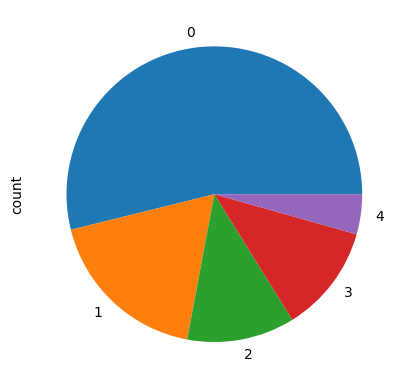

In [12]:
df_heart_no_missing['num'].value_counts().plot(kind='pie')

**Task 2.2**

In [13]:
df_heart_no_missing.describe()

,age,trestbps,chol,thalach,oldpeak,ca,num
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,131.693603,247.350168,149.599327,1.055556,0.676768,0.946128
std,9.049736,17.762806,51.997583,22.941562,1.166123,0.938965,1.234551
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000,0.000000,0.000000
50%,56.000000,130.000000,243.000000,153.000000,0.800000,0.000000,0.000000
75%,61.000000,140.000000,276.000000,166.000000,1.600000,1.000000,2.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,3.000000,4.000000


**Task 2.3**

In [14]:
# not the best way to go - we see also numerical columns in the results
df_heart_no_missing.mode()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,58.0,1,4,120.0,197,0,0,162.0,0,0.0,1,0.0,3.0,0.0
1,NaN,NaN,NaN,NaN,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df_heart_no_missing.loc[:, cat_names].mode()

,sex,cp,fbs,restecg,exang,slope,thal
0,1,4,0,0,0,1,3.0


**Task 2.4**

In [16]:
corr_matrix = df_heart_no_missing.corr(method='pearson', numeric_only=True)

In [17]:
import seaborn as sns

<Axes: >

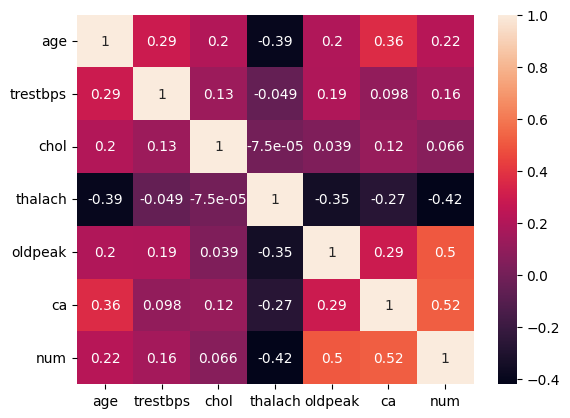

In [18]:
sns.heatmap(corr_matrix, annot=True)

**Task 2.5**

In [19]:
corr_matrix['age'].abs()[1:].nlargest(3)
# corr_matrix['age'].abs().nlargest(3)

,age
thalach,0.394563
ca,0.362210
trestbps,0.290476


**Task 3**

In [20]:
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

df_adult = pd.concat([X, y], axis=1)

In [21]:
df_adult.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Task 3.1**

In [22]:
cat_names = adult.variables[adult.variables['type'] == 'Categorical']['name']
for feature_name in cat_names:
    df_adult[feature_name] = df_adult[feature_name].astype('category')

In [23]:
import scipy.stats as stats

group_white = df_adult[df_adult['race'] == 'White']['capital-gain']
group_other = df_adult[df_adult['race'] != 'White']['capital-gain']

t_stat, p_val = stats.ttest_ind(group_white, group_other, equal_var=False, alternative='greater')
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: 3.607743754300278, P-value: 0.0001551525482882344


**Task 4**

In [24]:
import numpy as np

df_adult['age_group'] = np.where(df_adult['age'] < 40, '<40', '>=40')
contingency_table = pd.crosstab(df_adult['age_group'], df_adult['income'])

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi2: {chi2}, P-value: {p_val}")

Chi2: 2545.489163578558, P-value: 0.0
